# Learn LangGraph Conditional Edge Concept with Making Lemon Juice

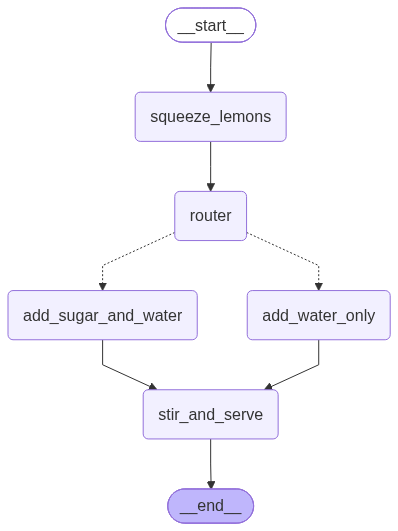


🧪 Sugar = 2
Juice from 4 lemons + 2 spoons sugar + 1 glass water → Stirred and ready to serve!

🧪 Sugar = 0
Juice from 4 lemons + 1 glass water → Stirred and ready to serve!


In [1]:
from langgraph.graph import StateGraph
from typing import TypedDict, Dict, Any
from IPython.display import Image, display

# Define state
class LemonState(TypedDict):
    lemons: int
    sugar: int
    water: str
    juice: str
    mix: str
    final: str

# Real processing nodes
def squeeze_lemons(state: Dict[str, Any]) -> Dict[str, Any]:
    state["juice"] = f"Juice from {state.get('lemons', 0)} lemons"
    return state

def add_sugar_and_water(state: Dict[str, Any]) -> Dict[str, Any]:
    state["mix"] = f"{state['juice']} + {state['sugar']} spoons sugar + {state['water']} water"
    return state

def add_water_only(state: Dict[str, Any]) -> Dict[str, Any]:
    state["mix"] = f"{state['juice']} + {state['water']} water"
    return state

def stir_and_serve(state: Dict[str, Any]) -> Dict[str, Any]:
    state["final"] = f"{state['mix']} → Stirred and ready to serve!"
    return state

# Router node (dummy function that does nothing, just passes state)
def router_node(state: Dict[str, Any]) -> Dict[str, Any]:
    return state

# Decision logic
def check_sugar(state: Dict[str, Any]) -> str:
    return "add_sugar_and_water" if state.get("sugar", 0) > 0 else "add_water_only"

# Build graph
builder = StateGraph(LemonState)
builder.add_node("squeeze_lemons", squeeze_lemons)
builder.add_node("router", router_node)  # 🧠 decision point (actual node)
builder.add_node("add_sugar_and_water", add_sugar_and_water)
builder.add_node("add_water_only", add_water_only)
builder.add_node("stir_and_serve", stir_and_serve)

# Flow setup
builder.set_entry_point("squeeze_lemons")
builder.add_edge("squeeze_lemons", "router")

# Now the router can conditionally branch
builder.add_conditional_edges("router", check_sugar, {
    "add_sugar_and_water": "add_sugar_and_water",
    "add_water_only": "add_water_only"
})

# Connect both to final step
builder.add_edge("add_sugar_and_water", "stir_and_serve")
builder.add_edge("add_water_only", "stir_and_serve")
builder.set_finish_point("stir_and_serve")

# Compile
graph = builder.compile()

# Visualize
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization failed:", e)

# Test cases
for sugar_amt in [2, 0]:
    print(f"\n🧪 Sugar = {sugar_amt}")
    result = graph.invoke({
        "lemons": 4,
        "sugar": sugar_amt,
        "water": "1 glass",
        "juice": "",
        "mix": "",
        "final": ""
    })
    print(result["final"])


LangGraph Conditional Workflow – Complete Code Explanation (Table Format)

This example demonstrates conditional routing in LangGraph. Based on the amount of sugar, the workflow chooses one of two different paths before producing the final lemonade.



Overall Workflow
                START
                  │
                  ▼
          Squeeze Lemons
                  │
                  ▼
             Router Node
                  │
        ┌─────────┴─────────┐
        ▼                   ▼
Sugar > 0             Sugar == 0
        │                   │
        ▼                   ▼
Add Sugar & Water    Add Water Only
        │                   │
        └─────────┬─────────┘
                  ▼
          Stir & Serve
                  │
                  ▼
                 END

Import Statements

| Code                                         | Purpose          | Description                                                    |
| -------------------------------------------- | ---------------- | -------------------------------------------------------------- |
| `from langgraph.graph import StateGraph`     | Import LangGraph | Imports the graph builder used to create workflows.            |
| `from typing import TypedDict, Dict, Any`    | Import Typing    | Imports data types for defining the state and node functions.  |
| `from IPython.display import Image, display` | Display Graph    | Used to display the Mermaid workflow diagram in Colab/Jupyter. |

====

2. Define State

| Code                           | Purpose      | Description                                           |
| ------------------------------ | ------------ | ----------------------------------------------------- |
| `class LemonState(TypedDict):` | Create State | Defines the shared state structure used by all nodes. |
| `lemons: int`                  | Input        | Stores the number of lemons.                          |
| `sugar: int`                   | Input        | Stores the sugar amount.                              |
| `water: str`                   | Input        | Stores the water quantity/type.                       |
| `juice: str`                   | Output       | Stores the squeezed lemon juice.                      |
| `mix: str`                     | Output       | Stores the prepared mixture.                          |
| `final: str`                   | Output       | Stores the finished lemonade message.                 |


====

Node – Squeeze Lemons

| Code                         | Purpose      | Description                                |
| ---------------------------- | ------------ | ------------------------------------------ |
| `def squeeze_lemons(state):` | Create Node  | First node in the workflow.                |
| `state["juice"] = ...`       | Update State | Creates juice from the lemons.             |
| `return state`               | Return       | Passes the updated state to the next node. |


====

4. Node – Add Sugar & Water

| Code                              | Purpose      | Description                               |
| --------------------------------- | ------------ | ----------------------------------------- |
| `def add_sugar_and_water(state):` | Create Node  | Executes when sugar is greater than zero. |
| `state["mix"] = ...`              | Update State | Mixes juice, sugar, and water.            |
| `return state`                    | Return       | Passes the updated state onward.          |


====

5. Node – Add Water Only

| Code                         | Purpose      | Description                      |
| ---------------------------- | ------------ | -------------------------------- |
| `def add_water_only(state):` | Create Node  | Executes when sugar is zero.     |
| `state["mix"] = ...`         | Update State | Mixes only juice and water.      |
| `return state`               | Return       | Passes the updated state onward. |


=====

6. Node – Stir & Serve

| Code                         | Purpose      | Description                         |
| ---------------------------- | ------------ | ----------------------------------- |
| `def stir_and_serve(state):` | Create Node  | Final node in the workflow.         |
| `state["final"] = ...`       | Update State | Creates the final lemonade message. |
| `return state`               | Return       | Returns the completed state.        |


====

7. Router Node

| Code                      | Purpose     | Description                                                                     |
| ------------------------- | ----------- | ------------------------------------------------------------------------------- |
| `def router_node(state):` | Router Node | Represents the decision point in the workflow.                                  |
| `return state`            | Pass State  | Does not change the state; simply forwards it to the conditional routing logic. |


===

Why is this needed?

The router acts like a traffic police officer. It doesn't make lemonade—it only directs the workflow to the correct path.

====

8. Decision Function

| Code                           | Purpose           | Description                                       |
| ------------------------------ | ----------------- | ------------------------------------------------- |
| `def check_sugar(state):`      | Decision Function | Checks the sugar value in the state.              |
| `return "add_sugar_and_water"` | Branch            | If sugar is greater than 0, go to the sugar node. |
| `return "add_water_only"`      | Branch            | If sugar is 0, go to the water-only node.         |


====

9. Create Graph

| Code                               | Purpose      | Description                                       |
| ---------------------------------- | ------------ | ------------------------------------------------- |
| `builder = StateGraph(LemonState)` | Create Graph | Creates a workflow using the `LemonState` schema. |


====

10. Add Nodes

| Code                                                           | Purpose         | Description                    |
| -------------------------------------------------------------- | --------------- | ------------------------------ |
| `builder.add_node("squeeze_lemons", squeeze_lemons)`           | Register Node   | Adds the squeeze node.         |
| `builder.add_node("router", router_node)`                      | Register Router | Adds the decision node.        |
| `builder.add_node("add_sugar_and_water", add_sugar_and_water)` | Register Node   | Adds the sugar path node.      |
| `builder.add_node("add_water_only", add_water_only)`           | Register Node   | Adds the water-only path node. |
| `builder.add_node("stir_and_serve", stir_and_serve)`           | Register Node   | Adds the final node.           |

====

11. Entry Point

| Code                                        | Purpose    | Description                                     |
| ------------------------------------------- | ---------- | ----------------------------------------------- |
| `builder.set_entry_point("squeeze_lemons")` | Start Node | The workflow always starts by squeezing lemons. |


=====

12. Normal Edge


| Code                                           | Purpose       | Description                                   |
| ---------------------------------------------- | ------------- | --------------------------------------------- |
| `builder.add_edge("squeeze_lemons", "router")` | Connect Nodes | Connects the squeeze node to the router node. |


====

13. Conditional Edge ⭐

| Code                                 | Purpose             | Description                                           |
| ------------------------------------ | ------------------- | ----------------------------------------------------- |
| `builder.add_conditional_edges(...)` | Conditional Routing | Creates multiple possible paths based on a condition. |
| `"router"`                           | Source Node         | The router is where the decision happens.             |
| `check_sugar`                        | Decision Function   | Determines which path should be taken.                |
| `{...}`                              | Route Map           | Maps decision results to destination nodes.           |


====

Decision Table

| Sugar Value | Decision Function Returns | Next Node         |
| ----------- | ------------------------- | ----------------- |
| `2`         | `"add_sugar_and_water"`   | Add Sugar & Water |
| `0`         | `"add_water_only"`        | Add Water Only    |


===

14. Merge Paths

| Code                                                        | Purpose | Description                                     |
| ----------------------------------------------------------- | ------- | ----------------------------------------------- |
| `builder.add_edge("add_sugar_and_water", "stir_and_serve")` | Merge   | Connects the sugar path to the final node.      |
| `builder.add_edge("add_water_only", "stir_and_serve")`      | Merge   | Connects the water-only path to the final node. |


Both branches meet at the same final step.

====

15. Finish Point

| Code                                         | Purpose  | Description                          |
| -------------------------------------------- | -------- | ------------------------------------ |
| `builder.set_finish_point("stir_and_serve")` | End Node | Marks the workflow completion point. |


====



16. Compile Graph

| Code                        | Purpose                | Description                                                    |
| --------------------------- | ---------------------- | -------------------------------------------------------------- |
| `graph = builder.compile()` | Build Executable Graph | Converts the workflow definition into an executable LangGraph. |


====

17. Visualize Graph

| Code                  | Purpose         | Description                                                                 |
| --------------------- | --------------- | --------------------------------------------------------------------------- |
| `display(Image(...))` | Display Diagram | Generates and displays the Mermaid graph.                                   |
| `try / except`        | Error Handling  | Prevents the program from crashing if Mermaid dependencies are unavailable. |


===

18. Test Cases

| Code                       | Purpose          | Description                                       |
| -------------------------- | ---------------- | ------------------------------------------------- |
| `for sugar_amt in [2, 0]:` | Test Loop        | Runs the graph twice with different sugar values. |
| `graph.invoke({...})`      | Execute Workflow | Starts the graph using the given input state.     |
| `print(result["final"])`   | Display Result   | Prints the final lemonade message.                |


====



LangGraph Concepts Used

| Concept               | Code Used                 | Description                                                    |
| --------------------- | ------------------------- | -------------------------------------------------------------- |
| **State**             | `LemonState`              | Shared data passed through every node.                         |
| **Node**              | All processing functions  | Each node performs one specific task.                          |
| **Router Node**       | `router_node()`           | Decision point that forwards the state to conditional routing. |
| **Decision Function** | `check_sugar()`           | Determines which branch the graph follows.                     |
| **Conditional Edge**  | `add_conditional_edges()` | Creates different execution paths based on conditions.         |
| **Edge**              | `add_edge()`              | Connects nodes together.                                       |
| **Entry Point**       | `set_entry_point()`       | Defines where execution starts.                                |
| **Finish Point**      | `set_finish_point()`      | Defines where execution ends.                                  |
| **Compile**           | `builder.compile()`       | Produces the executable graph.                                 |
| **Invoke**            | `graph.invoke()`          | Runs the workflow with an input state.                         |
| **Visualization**     | `draw_mermaid_png()`      | Shows the workflow as a graph diagram.                         |


This example introduces conditional workflows, one of LangGraph's most powerful features. Unlike a simple linear graph, the workflow can choose different execution paths based on the current state. Here, the router node and check_sugar() function allow the graph to either add sugar or skip it, while both paths eventually converge at the same final node. This pattern is commonly used in real applications such as booking systems, customer support, and approval workflows where different decisions lead to different actions.